In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [5]:
data = pd.read_csv("Sample - Superstore.csv")
data.head()

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa0 in position 2961: invalid start byte

In [6]:
import pandas as pd

data = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
data['Order Date'] = pd.to_datetime(data['Order Date'])

ValueError: time data "4/15/2017" doesn't match format "%m-%d-%Y", at position 4. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [8]:
data['Order Date'] = pd.to_datetime(data['Order Date'], format='%m/%d/%Y')

ValueError: time data "11-08-2016" doesn't match format "%m/%d/%Y", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [9]:
data['Order Date'] = pd.to_datetime(data['Order Date'], format='mixed')

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   object        
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [11]:
daily_sales.head()

NameError: name 'daily_sales' is not defined

In [12]:
daily_sales = data.groupby('Order Date')['Sales'].sum().reset_index()

In [13]:
daily_sales.head()

,Order Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


In [15]:
daily_sales.shape

(1237, 2)

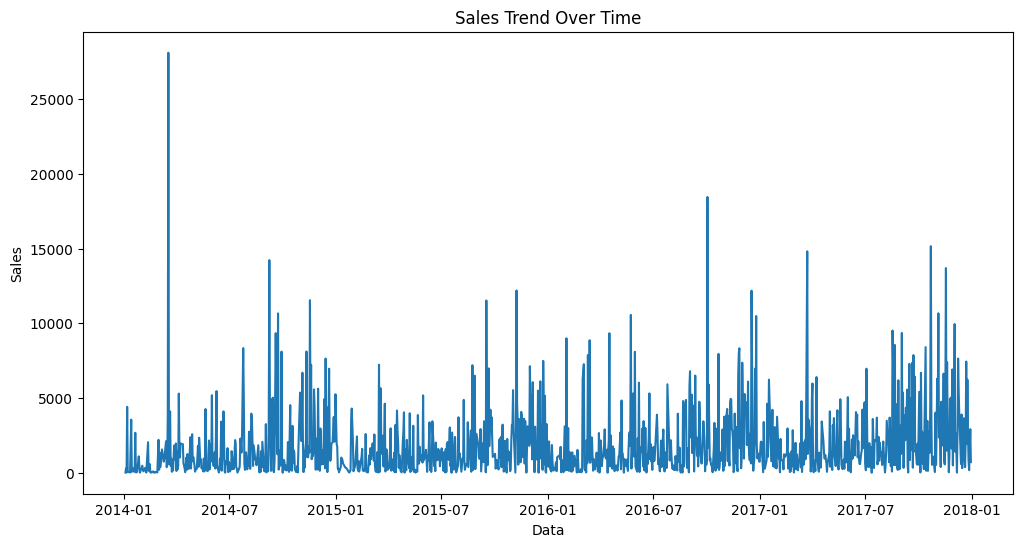

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(daily_sales['Order Date'], daily_sales['Sales'])
plt.title("Sales Trend Over Time")
plt.xlabel("Data")
plt.ylabel("Sales")
plt.show()

In [17]:
daily_sales['year'] = daily_sales['Order Date'].dt.year
daily_sales['month'] = daily_sales['Order Date'].dt.month
daily_sales['day'] = daily_sales['Order Date'].dt.day
daily_sales['day_of_week'] = daily_sales['Order Date'].dt.day_of_week




In [18]:
daily_sales.head()

,Order Date,Sales,year,month,day,day_of_week
0,2014-01-03,16.448,2014,1,3,4
1,2014-01-04,288.060,2014,1,4,5
2,2014-01-05,19.536,2014,1,5,6
3,2014-01-06,4407.100,2014,1,6,0
4,2014-01-07,87.158,2014,1,7,1


In [20]:
X = daily_sales[['year','month','day','day_of_week']]
y = daily_sales['Sales']

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

In [22]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [23]:
predictions = model.predict(X_test)

In [24]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, predictions)
print("Mean Absoulte Error", mae)

Mean Absoulte Error 1861.656300548387


In [25]:
daily_sales['Sales'].describe()

,Sales
count,1237.000000
mean,1857.074261
std,2305.538776
min,2.025000
25%,377.736000
50%,1063.185000
75%,2395.786000
max,28106.716000


Text(0, 0.5, 'Sales')

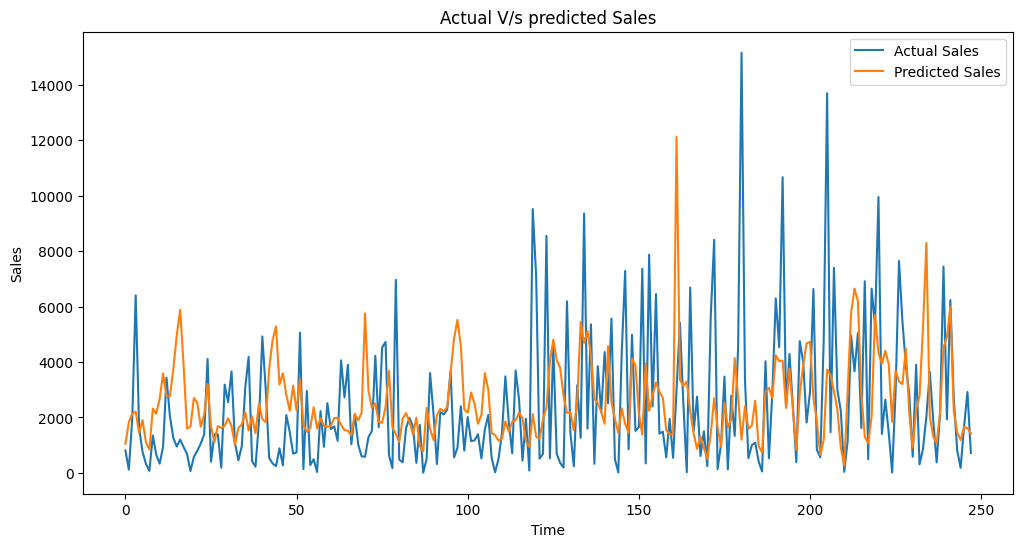

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual Sales")
plt.plot(predictions, label="Predicted Sales")
plt.legend()
plt.title("Actual V/s predicted Sales")
plt.xlabel("Time")
plt.ylabel("Sales")

In [27]:
plt.show()

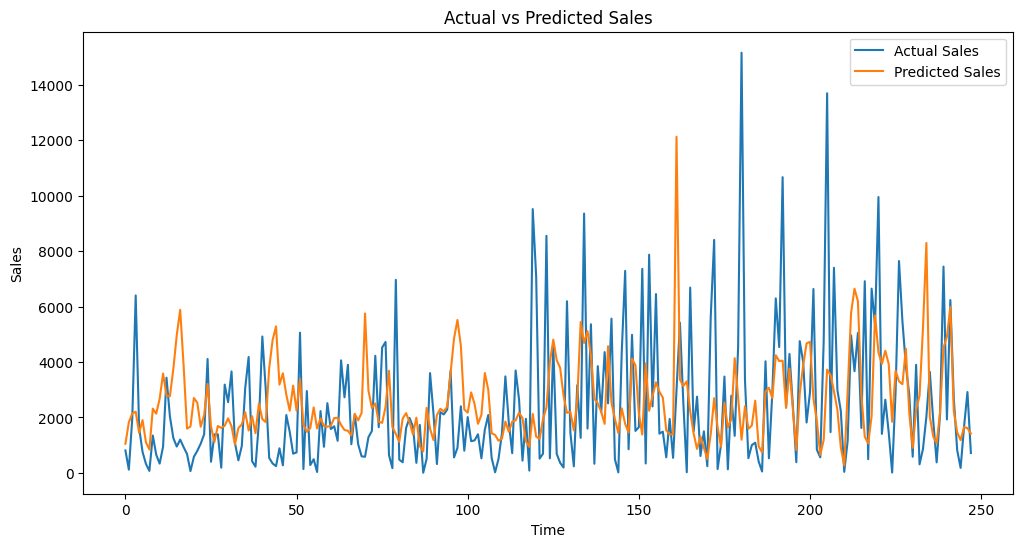

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual Sales")
plt.plot(predictions, label="Predicted Sales")

plt.legend()

plt.title("Actual vs Predicted Sales")
plt.xlabel("Time")
plt.ylabel("Sales")

plt.show()

In [31]:
future_sales = pd.date_range(
    start = daily_sales['Order Date'].max(),
    periods=30
)

In [32]:
future_df = pd.DataFrame({'Order Date' : future_sales})

In [33]:
daily_sales['year'] = daily_sales['Order Date'].dt.year
daily_sales['month'] = daily_sales['Order Date'].dt.month
daily_sales['day'] = daily_sales['Order Date'].dt.day
daily_sales['day_of_week'] = daily_sales['Order Date'].dt.day_of_week

In [34]:
future_df.head()

,Order Date
0,2017-12-30
1,2017-12-31
2,2018-01-01
3,2018-01-02
4,2018-01-03


In [35]:
future_sales = model.predict(
    future_df[['year','month','day','day_of_week']]
)
future_df['Predicted sales'] = future_sales

KeyError: "None of [Index(['year', 'month', 'day', 'day_of_week'], dtype='object')] are in the [columns]"

In [36]:
future_df['year'] = future_df['Order Date'].dt.year
future_df['month'] = future_df['Order Date'].dt.month
future_df['day'] = future_df['Order Date'].dt.day
future_df['day_of_week'] = future_df['Order Date'].dt.dayofweek

In [37]:
future_df.head()

,Order Date,year,month,day,day_of_week
0,2017-12-30,2017,12,30,5
1,2017-12-31,2017,12,31,6
2,2018-01-01,2018,1,1,0
3,2018-01-02,2018,1,2,1
4,2018-01-03,2018,1,3,2


In [38]:
future_sales = model.predict(
    future_df[['year','month','day','day_of_week']]
)

future_df['Predicted Sales'] = future_sales

In [39]:
future_df.head()

,Order Date,year,month,day,day_of_week,Predicted Sales
0,2017-12-30,2017,12,30,5,1416.863570
1,2017-12-31,2017,12,31,6,3244.625454
2,2018-01-01,2018,1,1,0,2477.643460
3,2018-01-02,2018,1,2,1,3523.683640
4,2018-01-03,2018,1,3,2,1677.905250


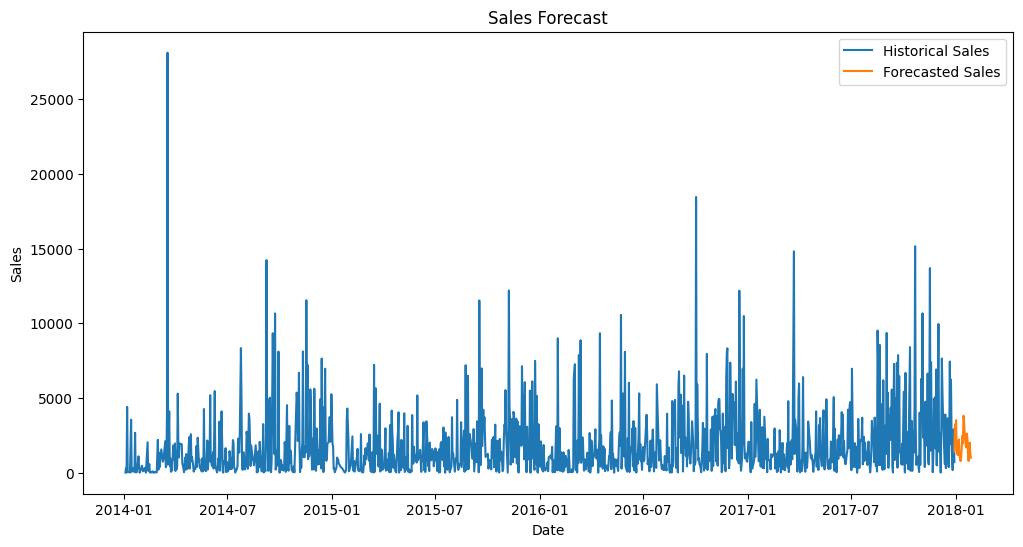

In [40]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(daily_sales['Order Date'], daily_sales['Sales'], label="Historical Sales")
plt.plot(future_df['Order Date'], future_df['Predicted Sales'], label="Forecasted Sales")
plt.legend()

plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()




In [41]:
forecast_output = future_df[['Order Date','Predicted Sales']]
forecast_output.head(10)

,Order Date,Predicted Sales
0,2017-12-30,1416.863570
1,2017-12-31,3244.625454
2,2018-01-01,2477.643460
3,2018-01-02,3523.683640
4,2018-01-03,1677.905250
5,2018-01-04,1259.136040
6,2018-01-05,1180.708304
7,2018-01-06,2004.696080
8,2018-01-07,2227.680180
9,2018-01-08,1237.625170


In [42]:
forecast_output.to_csv("sales_forecast_results.csv", index=False)

In [43]:
from google.colab import files
files.download("sales_forecast_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
import pickle
with open("sales_forecast_results.pkl", "wb") as f:
  pickle.dump(model, f)


In [45]:
from google.colab import files
files.download("sales_forecast_results.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_267/3743588114.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = daily_sales.resample('M', on='Order Date').sum()


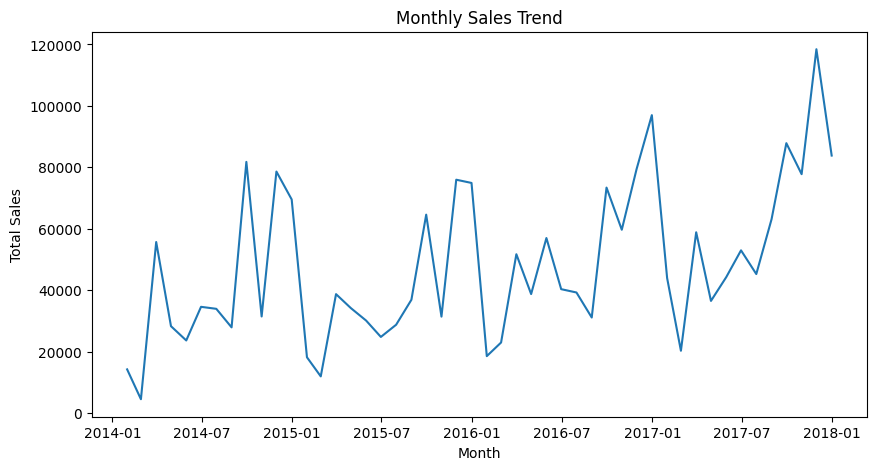

In [46]:
monthly_sales = daily_sales.resample('M', on='Order Date').sum()

plt.figure(figsize=(10,5))

plt.plot(monthly_sales.index, monthly_sales['Sales'])

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

Forecast Meaning

The machine learning model analyzes historical sales patterns and predicts future demand based on time-related features such as month, day, and day of week.

Business Use

Businesses can use the forecast to:

plan inventory levels

prepare staffing schedules

manage supply chain operations

reduce stock shortages

Example Insight

If the forecast predicts higher demand in upcoming days, the business can increase inventory to ensure product availability.